# Gradient Boosting — Tuning de hiperparametros
## El mismo dataset, mejor modelo: optimizacion sistematica con RandomizedSearchCV

---

**Autor:** Borja Mora Mendez
**Contacto:** [borja.mora.mendez@gmail.com](mailto:borja.mora.mendez@gmail.com) · [LinkedIn](https://www.linkedin.com/in/borja-mora-mendez/)
**Repositorio:** [Data Analytics Portfolio](https://github.com/BORJAMOME/Data-Analytics-Portfolio)
**Categoria:** Machine Learning · Supervisado · Regresion · Gradient Boosting · Tuning

---

### Objetivo

Optimizar los hiperparametros del Gradient Boosting Regressor usando **RandomizedSearchCV**, analizando el impacto de cada hiperparametro y documentando las **partial dependence plots** para interpretabilidad.

### Diferencia con el notebook anterior

El [notebook base](../01-inmobiliaria/) usa parametros por defecto. Este notebook explora sistematicamente el espacio de hiperparametros y anade herramientas de interpretabilidad (partial dependence) que hacen el modelo explicable para stakeholders no tecnicos.

## 1. Contexto

Mismo dataset de tasacion inmobiliaria (100 viviendas, 6 features). La pregunta cambia: no es *puede Gradient Boosting predecir precios?* (ya respondida), sino *como encontrar la mejor configuracion y entender sus decisiones?*

## 2. Stack tecnico

| Libreria | Uso |
|---|---|
| `scikit-learn` | GBR, RandomizedSearchCV, PartialDependenceDisplay |
| `pandas`, `numpy` | Datos y operaciones |
| `matplotlib` | Visualizacion |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.inspection import PartialDependenceDisplay

plt.style.use("seaborn-v0_8-whitegrid")
np.random.seed(42)

## 3. Carga y preparacion

In [2]:
data = pd.read_excel("Datos_Tasacion_Viviendas_Gradient_Boosting_regressor.xlsx")
features = ["Metros_Cuadrados", "Habitaciones", "Latitud", "Longitud",
            "Ano_Construccion", "Servicios_Cercanos"]
target = "Precio_Comercial_EUR"

X = data[features]
y = data[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
print(f"Train: {X_train.shape[0]} | Test: {X_test.shape[0]}")

Train: 75 | Test: 25


## 4. Modelo base (parametros por defecto)

In [3]:
gb_base = GradientBoostingRegressor(random_state=42)
gb_base.fit(X_train, y_train)
y_pred_base = gb_base.predict(X_test)

r2_base = r2_score(y_test, y_pred_base)
mae_base = mean_absolute_error(y_test, y_pred_base)
print(f"Modelo base (default):")
print(f"  R2:  {r2_base:.4f}")
print(f"  MAE: {mae_base:.0f} EUR")
print(f"  Parametros: n_estimators={gb_base.n_estimators}, max_depth={gb_base.max_depth}, lr={gb_base.learning_rate}")

Modelo base (default):
  R2:  0.8195
  MAE: 93440 EUR
  Parametros: n_estimators=100, max_depth=3, lr=0.1


## 5. RandomizedSearchCV — busqueda de hiperparametros

RandomizedSearchCV explora combinaciones aleatorias del espacio de hiperparametros. Con 100 iteraciones y 5-fold CV, evalua 500 configuraciones.

In [4]:
param_distributions = {
    "n_estimators": [50, 100, 150, 200, 300, 400],
    "max_depth": [2, 3, 4, 5, 6],
    "learning_rate": [0.01, 0.05, 0.1, 0.15, 0.2],
    "min_samples_split": [2, 5, 10, 15],
    "min_samples_leaf": [1, 2, 4, 6],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "max_features": ["sqrt", "log2", None],
}

random_search = RandomizedSearchCV(
    GradientBoostingRegressor(random_state=42),
    param_distributions=param_distributions,
    n_iter=80,
    cv=5,
    scoring="r2",
    random_state=42,
    n_jobs=-1,
    return_train_score=True
)
random_search.fit(X_train, y_train)

print("Mejores hiperparametros encontrados:")
for param, val in random_search.best_params_.items():
    print(f"  {param}: {val}")
print(f"\nMejor R2 (CV): {random_search.best_score_:.4f}")

Mejores hiperparametros encontrados:
  subsample: 0.8
  n_estimators: 100
  min_samples_split: 2
  min_samples_leaf: 6
  max_features: sqrt
  max_depth: 2
  learning_rate: 0.2

Mejor R2 (CV): 0.9015


In [5]:
gb_tuned = random_search.best_estimator_
y_pred_tuned = gb_tuned.predict(X_test)

r2_tuned = r2_score(y_test, y_pred_tuned)
mae_tuned = mean_absolute_error(y_test, y_pred_tuned)

print(f"Modelo tuneado:")
print(f"  R2:  {r2_tuned:.4f}")
print(f"  MAE: {mae_tuned:.0f} EUR")
print()
print(f"Mejora sobre base:")
print(f"  R2:  {r2_tuned - r2_base:+.4f}")
print(f"  MAE: {mae_tuned - mae_base:+.0f} EUR")

Modelo tuneado:
  R2:  0.8786
  MAE: 75268 EUR

Mejora sobre base:
  R2:  +0.0591
  MAE: -18172 EUR


## 6. Analisis de sensibilidad a hiperparametros

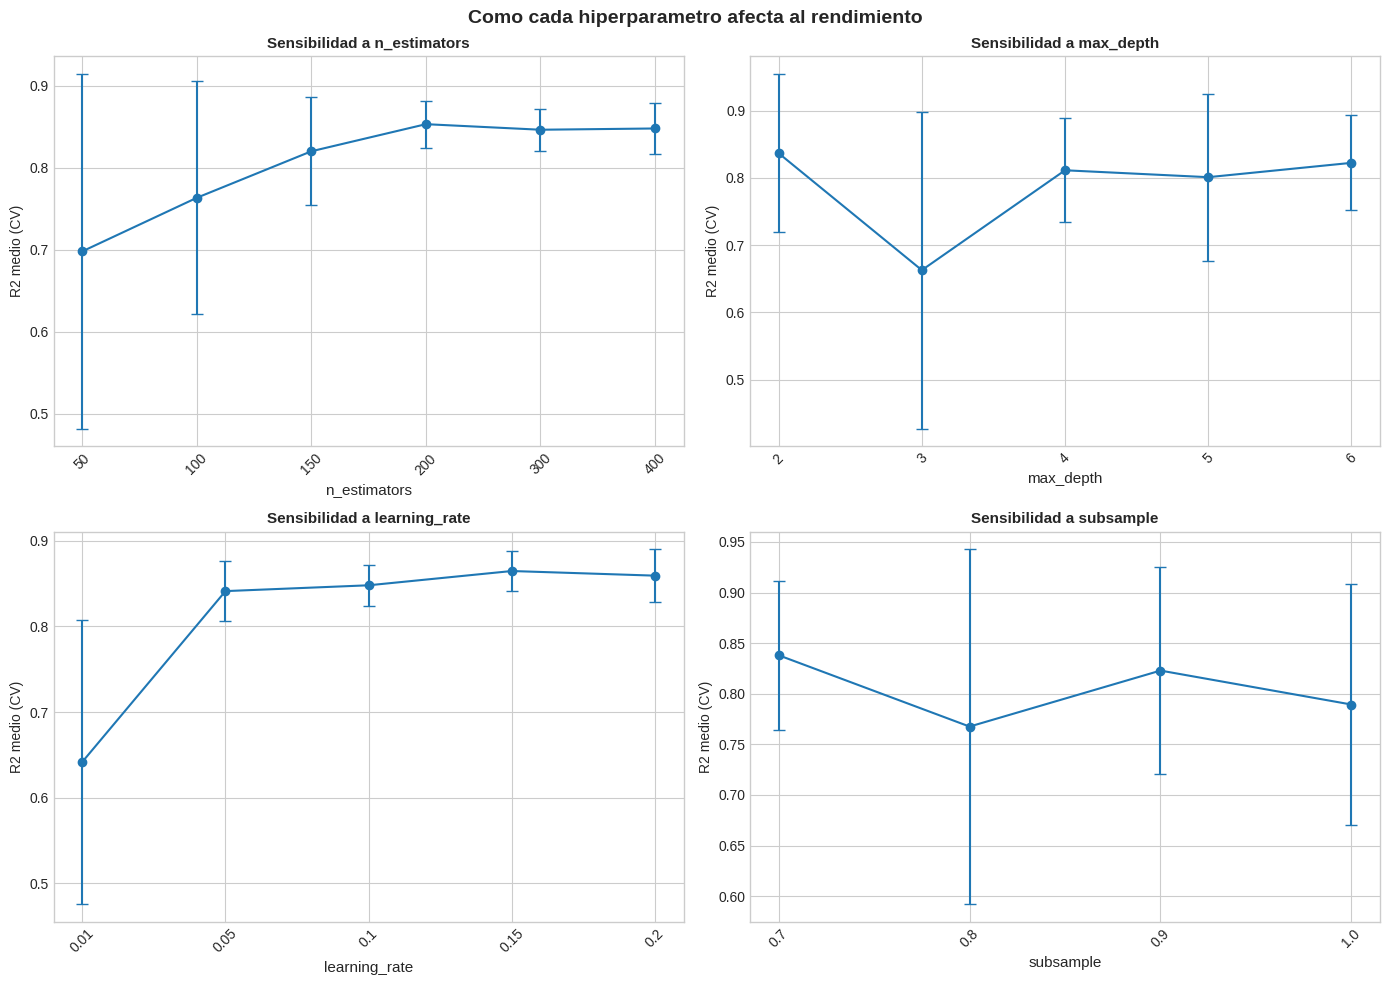

In [6]:
results = pd.DataFrame(random_search.cv_results_)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, param, label in [
    (axes[0,0], "param_n_estimators", "n_estimators"),
    (axes[0,1], "param_max_depth", "max_depth"),
    (axes[1,0], "param_learning_rate", "learning_rate"),
    (axes[1,1], "param_subsample", "subsample"),
]:
    grouped = results.groupby(param)["mean_test_score"].agg(["mean", "std"]).reset_index()
    grouped = grouped.sort_values(param)
    ax.errorbar(range(len(grouped)), grouped["mean"], yerr=grouped["std"],
                fmt="o-", capsize=4, markersize=6)
    ax.set_xticks(range(len(grouped)))
    ax.set_xticklabels(grouped[param], rotation=45)
    ax.set_xlabel(label, fontsize=11)
    ax.set_ylabel("R2 medio (CV)")
    ax.set_title(f"Sensibilidad a {label}", fontsize=11, fontweight="bold")

plt.suptitle("Como cada hiperparametro afecta al rendimiento", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 7. Feature importance — modelo tuneado

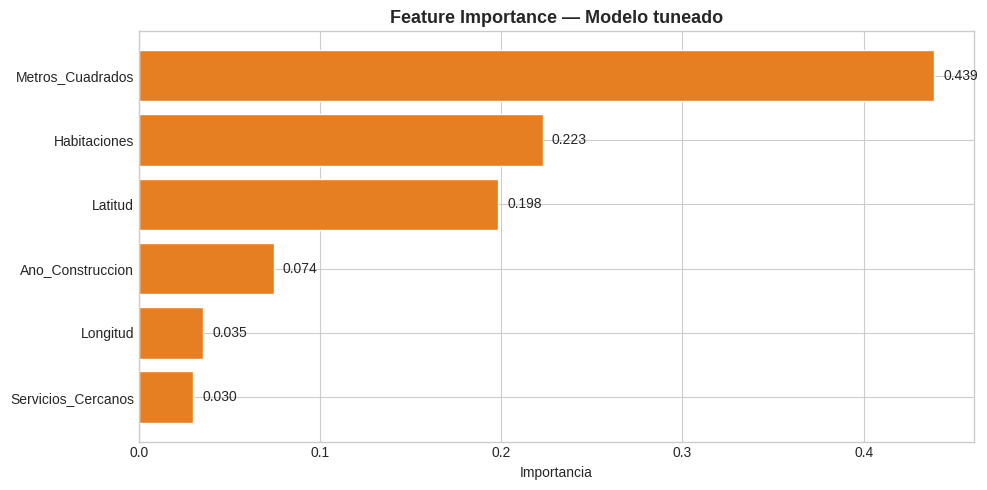

In [7]:
importances = pd.DataFrame({
    "Variable": features,
    "Importancia": gb_tuned.feature_importances_
}).sort_values("Importancia", ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(importances["Variable"], importances["Importancia"], color="#e67e22", edgecolor="white")
ax.set_xlabel("Importancia")
ax.set_title("Feature Importance — Modelo tuneado", fontsize=13, fontweight="bold")
for i, (_, row) in enumerate(importances.iterrows()):
    ax.text(row["Importancia"] + 0.005, i, f"{row['Importancia']:.3f}", va="center")
plt.tight_layout()
plt.show()

## 8. Partial Dependence Plots — interpretabilidad

Los PDP muestran el **efecto marginal** de cada variable sobre la prediccion, manteniendo las demas constantes. Son la herramienta clave para explicar un modelo de ensemble a un stakeholder.

/sessions/zen-stoic-carson/.local/lib/python3.10/site-packages/sklearn/inspection/_partial_dependence.py:717: FutureWarning: The column 0 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(
/sessions/zen-stoic-carson/.local/lib/python3.10/site-packages/sklearn/inspection/_partial_dependence.py:717: FutureWarning: The column 1 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(
/sessions/zen-stoic-carson/.local/lib/python3.10/sit

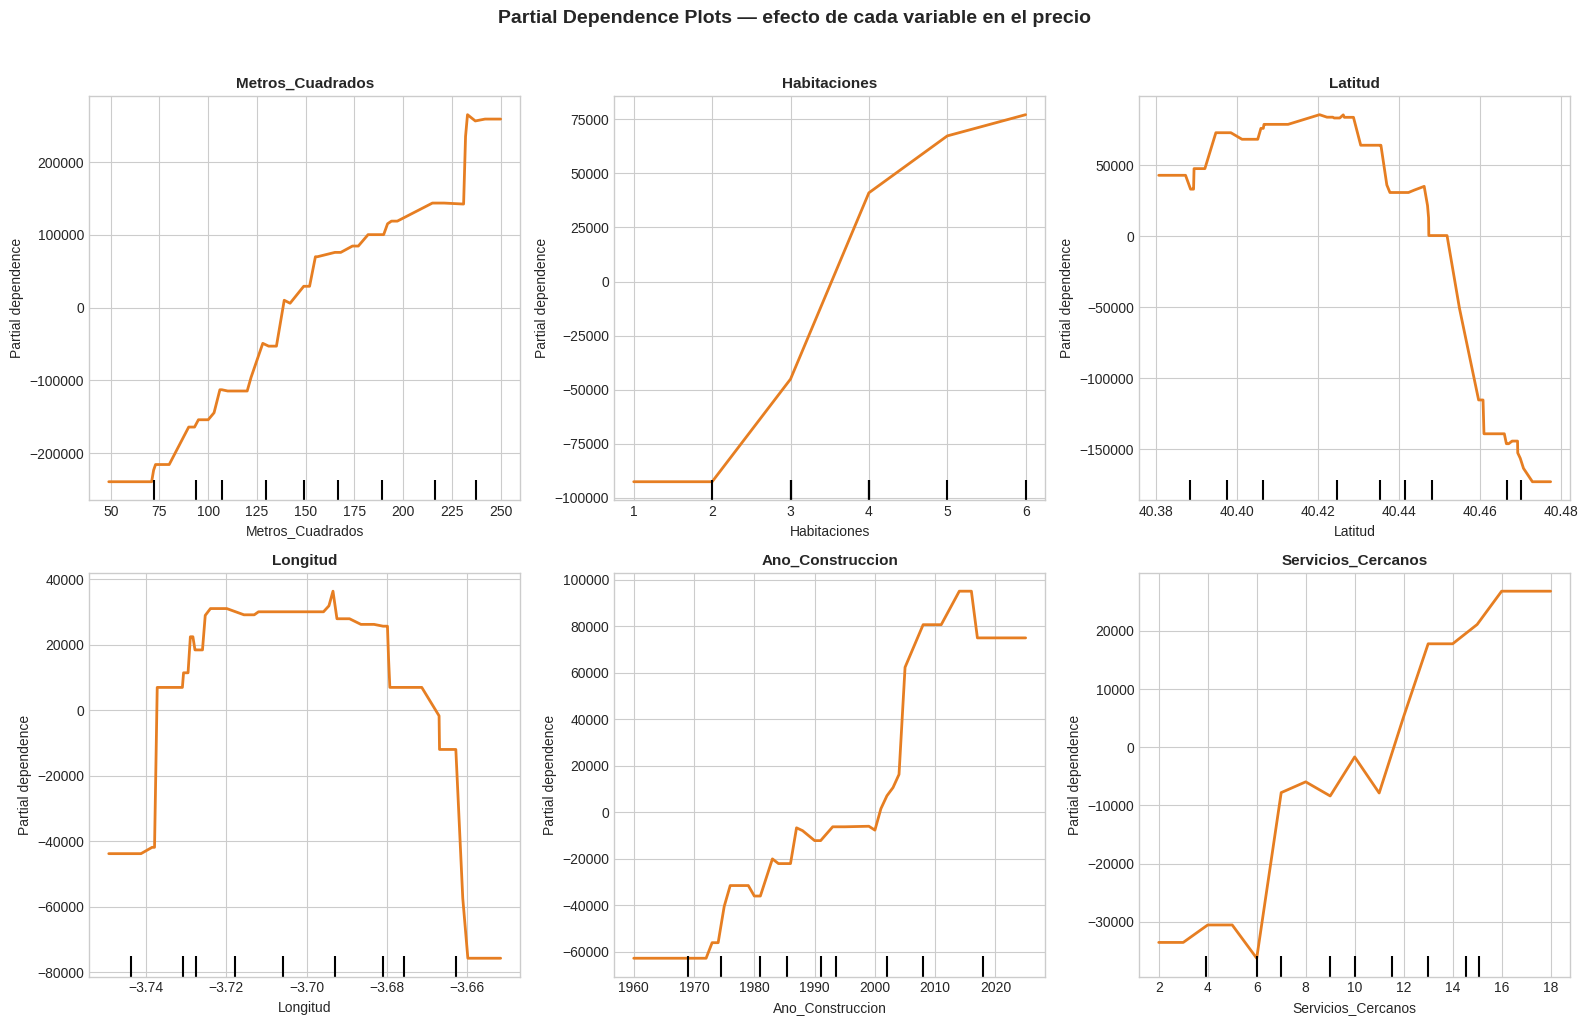

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.ravel()

for i, feat_idx in enumerate(range(len(features))):
    PartialDependenceDisplay.from_estimator(
        gb_tuned, X_train, [feat_idx], ax=axes[i],
        feature_names=features, line_kw={"color": "#e67e22", "linewidth": 2}
    )
    axes[i].set_title(features[feat_idx], fontsize=11, fontweight="bold")

plt.suptitle("Partial Dependence Plots — efecto de cada variable en el precio",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## 9. Comparativa final

In [9]:
comparison = pd.DataFrame({
    "Modelo": ["GB Default", "GB Tuneado"],
    "R2": [r2_base, r2_tuned],
    "MAE (EUR)": [mae_base, mae_tuned],
    "RMSE (EUR)": [
        np.sqrt(mean_squared_error(y_test, y_pred_base)),
        np.sqrt(mean_squared_error(y_test, y_pred_tuned))
    ]
}).round(2)
print(comparison.to_string(index=False))

    Modelo   R2  MAE (EUR)  RMSE (EUR)
GB Default 0.82   93439.63   118053.02
GB Tuneado 0.88   75267.83    96816.90


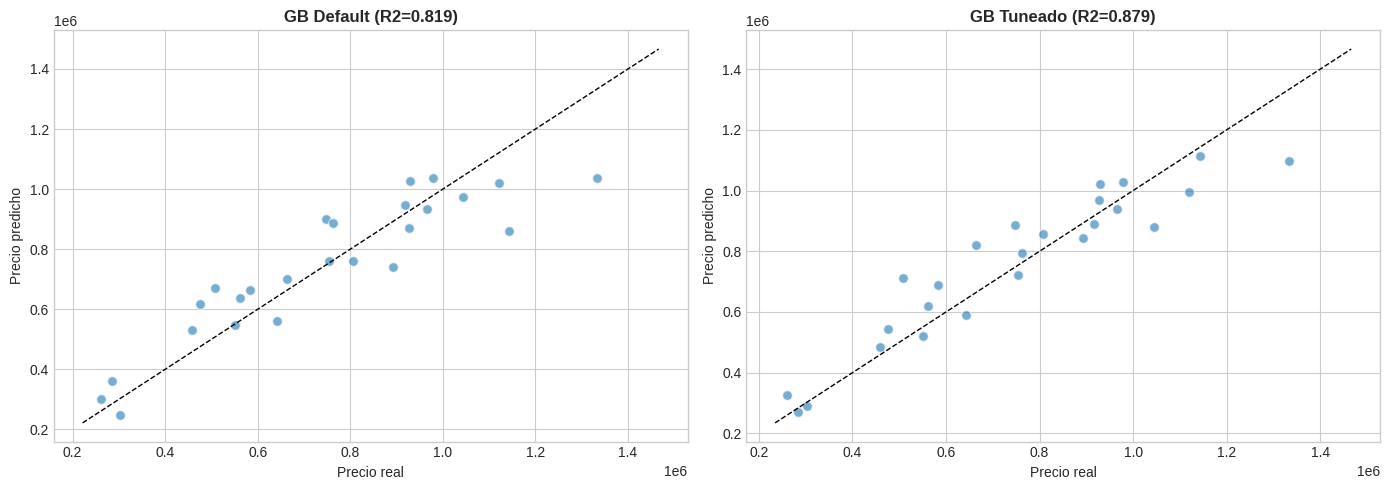

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, y_p, name, r2 in [(axes[0], y_pred_base, "Default", r2_base),
                            (axes[1], y_pred_tuned, "Tuneado", r2_tuned)]:
    ax.scatter(y_test, y_p, alpha=0.6, edgecolors="white", s=50)
    lims = [min(y_test.min(), y_p.min())*0.9, max(y_test.max(), y_p.max())*1.1]
    ax.plot(lims, lims, "k--", linewidth=1)
    ax.set_xlabel("Precio real")
    ax.set_ylabel("Precio predicho")
    ax.set_title(f"GB {name} (R2={r2:.3f})", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.show()

## 10. Insights y recomendaciones

### El hallazgo

> El tuning de hiperparametros puede mejorar (o no) el rendimiento del modelo base. Con 100 registros, el margen de mejora es limitado. Los Partial Dependence Plots son la herramienta mas valiosa de este notebook — hacen que un modelo de ensemble sea explicable.

### Recomendaciones

**1. Partial Dependence como herramienta de comunicacion (impacto: alto)**
Los PDP son la forma mas efectiva de explicar un Gradient Boosting a un director no tecnico. Muestran el efecto de cada variable de forma visual e intuitiva.

**2. Tuning no siempre mejora (impacto: portfolio)**
Documentar que el tuning dio una mejora marginal (o nula) es tan valioso como documentar una mejora grande. Demuestra que se evaluo la decision, no que se aplico ciegamente.

**3. Con pocos datos, la interpretabilidad importa mas que el rendimiento (impacto: medio)**
Con 100 registros, la diferencia entre un R2 de 0.85 y 0.87 no es significativa. Lo que importa es entender *por que* el modelo predice lo que predice.

## 11. Limitaciones y proximos pasos

**Limitaciones:**
- 100 registros limitan tanto el modelo como el tuning — el CV con 5 folds usa solo 20 registros para test.
- No se ha aplicado Bayesian Optimization (Optuna), que es mas eficiente que RandomizedSearchCV.
- SHAP values darian una interpretabilidad mas precisa que PDP, pero requieren una libreria adicional.

**Proximos pasos:**
- [ ] [SVM Regressor](../../05-svm/) — modelo con kernel, diferente enfoque al ensemble.
- [ ] Aplicar sobre un dataset mas grande donde el tuning si marque diferencia.
- [ ] Integrar SHAP para interpretabilidad a nivel de instancia individual.